### Importing Libraries

In [1]:
#Importing the libraries for data manipulation and visualisation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


import warnings
warnings.filterwarnings('ignore')

C:\Users\HOME\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\HOME\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
C:\Users\HOME\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


### Loading the dataset and viewing

In [2]:
# Load the dataset
df = pd.read_csv('stroke_data.csv')
df_copy = pd.read_csv('stroke_data.csv')
df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
#get dimensions of the DataFrame
df.shape

(5110, 12)

In [4]:
#display concise summary of the DataFrame.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
#to check the number of unique features in each column
df.nunique().to_frame()

,0
id,5110
gender,3
age,104
hypertension,2
heart_disease,2
ever_married,2
work_type,5
Residence_type,2
avg_glucose_level,3979
bmi,418


In [6]:
#summary statistics of all objects columns 
df.describe(include='O')

,gender,ever_married,work_type,Residence_type,smoking_status
count,5110,5110,5110,5110,5110
unique,3,2,5,2,4
top,Female,Yes,Private,Urban,never smoked
freq,2994,3353,2925,2596,1892


In [7]:
#to view the number of patients with stroke (target)
num_stroke = df.stroke.value_counts().to_frame()
index = pd.Index(['No', 'Yes'])
num_stroke = num_stroke.set_index(index)
num_stroke

,stroke
No,4861
Yes,249


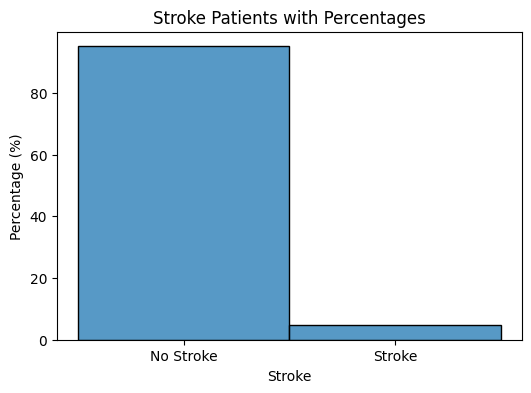

In [8]:
# Calculate the percentage of stroke presence and absence
num_stroke = df['stroke'].value_counts(normalize=True) * 100
# Create a DataFrame for the histplot
stroke_data = pd.DataFrame({'Stroke': num_stroke.index, 'Percentage': num_stroke.values})

# Create a histplot
plt.figure(figsize=(6, 4))
sns.histplot(data=stroke_data, x='Stroke', weights='Percentage', bins=2, discrete=True, palette=['lightblue', 'lightcoral'])
plt.xlabel('Stroke')
plt.ylabel('Percentage (%)')
plt.title('Stroke Patients with Percentages')
plt.xticks([0, 1], ['No Stroke', 'Stroke'])
plt.show()


## EDA AND DATA CLEANING

### Data Cleaning 

Summary Statistics:
                 id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.000000   
mean   36517.829354    43.226614      0.097456       0.054012   
std    21161.721625    22.612647      0.296607       0.226063   
min       67.000000     0.080000      0.000000       0.000000   
25%    17741.250000    25.000000      0.000000       0.000000   
50%    36932.000000    45.000000      0.000000       0.000000   
75%    54682.000000    61.000000      0.000000       0.000000   
max    72940.000000    82.000000      1.000000       1.000000   

       avg_glucose_level          bmi       stroke  
count        5110.000000  4909.000000  5110.000000  
mean          106.147677    28.893237     0.048728  
std            45.283560     7.854067     0.215320  
min            55.120000    10.300000     0.000000  
25%            77.245000    23.500000     0.000000  
50%            91.885000    28.100000     0.000000  
75%           114.09000

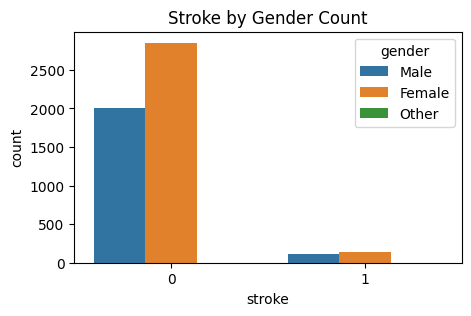

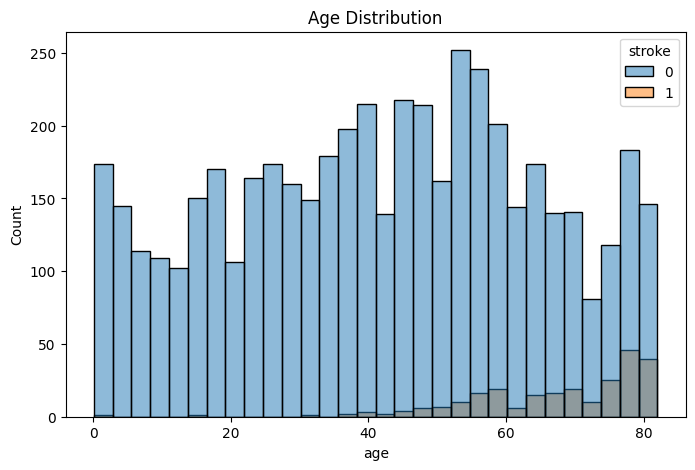

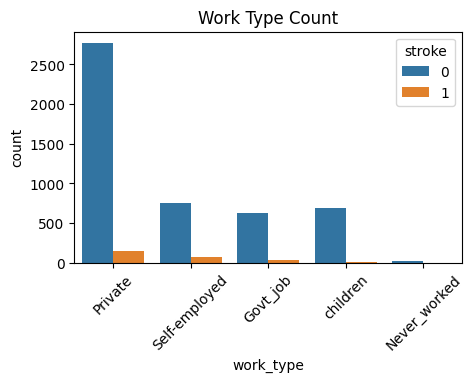

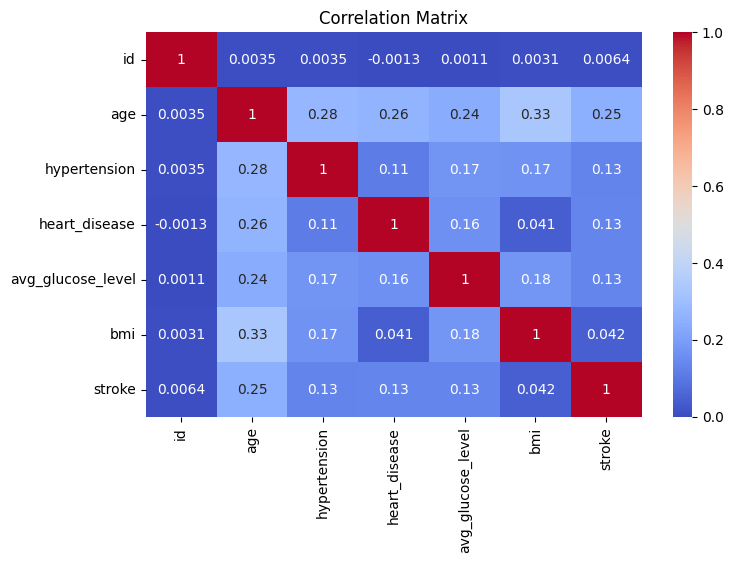

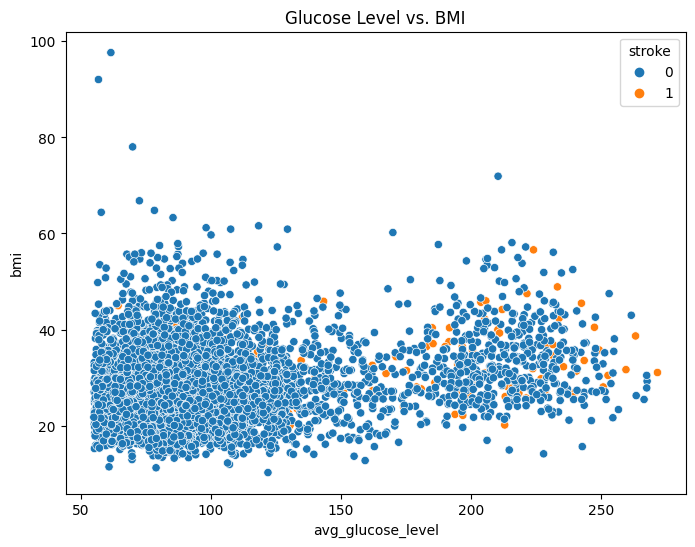

In [9]:
#function to visualise dataset individually and in different ways before cleaning
def visualize_dataset(df):
    # Summary statistics
    print("Summary Statistics:")
    print(df.describe())

    # Countplot of gender
    plt.figure(figsize=(5, 3))
    sns.countplot(data=df, x='stroke', hue='gender')
    plt.title("Stroke by Gender Count")
    plt.show()

    # Histogram of age
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x='age', hue= 'stroke', bins=30)
    plt.title("Age Distribution")
    plt.show()

    # Barplot of work type
    plt.figure(figsize=(5, 3))
    sns.countplot(data=df, x='work_type', hue= 'stroke')
    plt.title("Work Type Count")
    plt.xticks(rotation=45)  # Rotate x-axis labels by 45 degrees
    plt.show()

    # Correlation matrix
    plt.figure(figsize=(8, 5))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
    plt.title("Correlation Matrix")
    plt.show()

    # Scatterplot of glucose level vs. BMI
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x='avg_glucose_level', y='bmi', hue='stroke')
    plt.title("Glucose Level vs. BMI")
    plt.show()

#Call the visualize_dataset function
visualize_dataset(df)

In [10]:
#to drop the id column as it's not required
df = df.drop('id', axis=1)
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


### Gender cleaning

In [11]:
#gender cleaning
df['gender'].value_counts()

Female    2994
Male      2115
Other        1
Name: gender, dtype: int64

In [12]:
#replace other to the female gender as most occuring variable
df['gender'].replace({'Other':'Female'}, inplace=True) #replacing 'other' in gender with 'Female' being the mode of the series
df['gender'].value_counts()

Female    2995
Male      2115
Name: gender, dtype: int64

In [13]:
female = df[df['gender'] == 'Female']
male = df[df['gender'] == 'Male']

In [14]:
#get valuecounts for each gender's stroke patient
female.stroke.value_counts()

0    2854
1     141
Name: stroke, dtype: int64

In [15]:
male.stroke.value_counts()

0    2007
1     108
Name: stroke, dtype: int64

### Age cleaning

In [16]:
#not adding children and never worked in worktype for ages below 13
#list of rows with age less than 13 and working
df[(df['age']<13) & (df['work_type'].isin(['Private','Self-employed', 'Govt_job']))]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
251,Female,8.0,0,0,No,Private,Urban,110.89,17.6,Unknown,0
410,Male,7.0,0,0,No,Self-employed,Rural,64.06,18.9,Unknown,0


In [17]:
#drop columns
df = df.drop(df[(df['age'] < 13) & (df['work_type'].isin(['Private', 'Self-employed', 'Govt_job']))].index)

In [18]:
#check if columns have been dropped
df[(df['age']<13)&(df['work_type'].isin(['Private','Self-employed', 'Govt_job']))]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke


In [19]:
#group age by stroke
df.groupby('stroke').describe()['age']

,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
0,4859.0,41.985734,22.285549,0.08,24.0,43.0,59.0,82.0
1,249.0,67.728193,12.727419,1.32,59.0,71.0,78.0,82.0


### Age grouping

In [20]:
#we need to create a function for grouping our age so we can plot against other variables
def age_group(age):
    if age <= 49:
        return '0 - 49'
    elif age <= 59:
        return '50 - 59'
    elif age <= 69:
        return '60 - 69'
    elif age <= 79:
        return '70 - 79'
    elif age <= 89:
        return '80 - 89'
    else:
        return '89+'

In [21]:
#adding age-group class by applying the above function to age
df['age_group'] = df['age'].apply(age_group)
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,60 - 69
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,60 - 69
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,80 - 89
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,0 - 49
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,70 - 79


### BMI Cleaning

In [22]:
#checking for null values
df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
age_group              0
dtype: int64

In [23]:
#fill null values with mean of the column
df['bmi']=df['bmi'].fillna(df['bmi'].mean()).round()

In [24]:
#checking for null values
df.isna().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
age_group            0
dtype: int64

In [25]:
#checking for duplicates
#df.duplicated().sum()

### Average_glucose_level cleaning

In [26]:
#df.avg_glucose_level.value_counts()

In [27]:
#check for rows above and below the range of normal glucose level
filtered_df = df[(df['avg_glucose_level'] < 72) | (df['avg_glucose_level'] > 140)]
filtered_df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group
0,Male,67.00,0,1,Yes,Private,Urban,228.69,37.0,formerly smoked,1,60 - 69
1,Female,61.00,0,0,Yes,Self-employed,Rural,202.21,29.0,never smoked,1,60 - 69
3,Female,49.00,0,0,Yes,Private,Urban,171.23,34.0,smokes,1,0 - 49
4,Female,79.00,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,70 - 79
5,Male,81.00,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1,80 - 89
...,...,...,...,...,...,...,...,...,...,...,...,...
5086,Female,51.00,0,0,Yes,Private,Urban,152.56,22.0,Unknown,0,50 - 59
5089,Female,0.72,0,0,No,children,Rural,62.13,17.0,Unknown,0,0 - 49
5098,Male,9.00,0,0,No,children,Urban,71.88,18.0,Unknown,0,0 - 49
5100,Male,82.00,1,0,Yes,Self-employed,Rural,71.97,28.0,never smoked,0,80 - 89


In [28]:
#create a new column diabetes category to group the glucose levels
df["diabetes_cat"] = pd.cut(df["avg_glucose_level"],
                               bins=[0., 120, 141, np.inf],
                               labels=["no db", "pre db", "db"])
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group,diabetes_cat
0,Male,67.0,0,1,Yes,Private,Urban,228.69,37.0,formerly smoked,1,60 - 69,db
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,29.0,never smoked,1,60 - 69,db
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.0,never smoked,1,80 - 89,no db
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.0,smokes,1,0 - 49,db
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,70 - 79,db


In [29]:
#df[df["diabetes_cat"]=='db']["diabetes_cat"].value_counts()
#df[df["diabetes_cat"]

### Ever-married cleaning

In [30]:
#check for married patients less than legal age of marriage in uk 18
df[(df['age'] < 18) & (df['ever_married'] == 'Yes')]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group,diabetes_cat


In [31]:
df.shape

(5108, 13)

### Exploratory Data Analysis

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5108 entries, 0 to 5109
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   gender             5108 non-null   object  
 1   age                5108 non-null   float64 
 2   hypertension       5108 non-null   int64   
 3   heart_disease      5108 non-null   int64   
 4   ever_married       5108 non-null   object  
 5   work_type          5108 non-null   object  
 6   Residence_type     5108 non-null   object  
 7   avg_glucose_level  5108 non-null   float64 
 8   bmi                5108 non-null   float64 
 9   smoking_status     5108 non-null   object  
 10  stroke             5108 non-null   int64   
 11  age_group          5108 non-null   object  
 12  diabetes_cat       5108 non-null   category
dtypes: category(1), float64(3), int64(3), object(6)
memory usage: 523.9+ KB


In [33]:
#reset index of the dataframe
df = df.reset_index(drop=True)
#df

### Gender

In [34]:
#group the column gender by stroke, to note count of stroke in each gender
dataFrame =  pd.DataFrame({ 'stroke': ['Yes', 'No'], 'Female' : [141, 2854], 'Male': [108, 2007]})
dataFrame.index = dataFrame['stroke']
del dataFrame['stroke']
dataFrame

,Female,Male
stroke,,
Yes,141,108
No,2854,2007


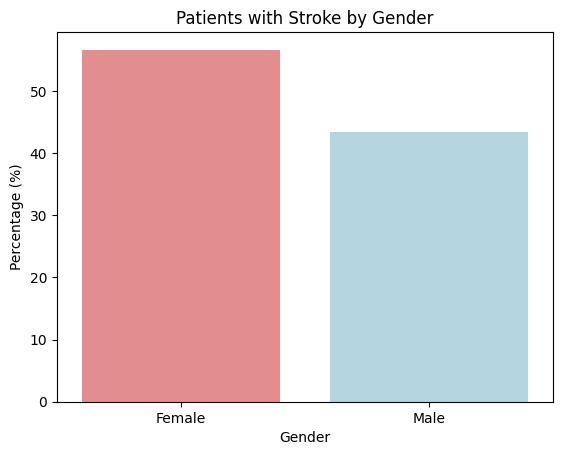

In [35]:
#data for stroke
gender_data = {
    'gender': ['Female', 'Male'],
    'stroke': [141, 108], 
}

dataFrame_gender = pd.DataFrame(gender_data)
total_strokes = df['stroke'].sum()
dataFrame_gender['percentage'] = (dataFrame_gender['stroke'] / total_strokes) * 100
sns.barplot(dataFrame_gender, x='gender', y='percentage', palette=['lightcoral', 'lightblue'],)
plt.xlabel('Gender')
plt.ylabel('Percentage (%)')
plt.title('Patients with Stroke by Gender')
plt.show()

### Age

In [36]:
##check for count of patients in each age group grouped by stroke**
df.age_group.value_counts()

0 - 49     2898
50 - 59     834
60 - 69     621
70 - 79     569
80 - 89     186
Name: age_group, dtype: int64

In [37]:
#df['age'].max()

In [38]:
# Define the age bins and group names
bins = [0, 49, 59, 69, 79, 89] 
age_group_names = ['Children', 'Adults', 'Mid-Age', 'Boomer', 'Generation X']
age_group = ['0-49', '50-59', '60-69', '70-79', '80-89']
# Add the age group column
df['age_group'] = pd.cut(df['age'], bins=bins, labels=age_group, right=False)

# Add the age-group names column
df['age_group_names'] = pd.cut(df['age'], bins=bins, labels=age_group_names, right=False)
df.head()


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group,diabetes_cat,age_group_names
0,Male,67.0,0,1,Yes,Private,Urban,228.69,37.0,formerly smoked,1,60-69,db,Mid-Age
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,29.0,never smoked,1,60-69,db,Mid-Age
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.0,never smoked,1,80-89,no db,Generation X
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.0,smokes,1,50-59,db,Adults
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,80-89,db,Generation X


In [39]:
df.age_group_names.value_counts()

Children        2819
Adults           833
Mid-Age          647
Boomer           538
Generation X     271
Name: age_group_names, dtype: int64

In [40]:
#function to group age-group names by stroke
def get_groupname_value_counts(df):
    
    # Group the data by group names and stroke
    groupname_counts = df.groupby('age_group_names')['stroke'].value_counts().unstack().fillna(0)
    
    return groupname_counts

In [41]:
groupname_counts = get_groupname_value_counts(df)
print(groupname_counts.transpose())

age_group_names  Children  Adults  Mid-Age  Boomer  Generation X
stroke                                                          
0                    2802     790      598     455           214
1                      17      43       49      83            57


### Hypertension

In [42]:
#count of patients with hypertension or not
df['hypertension'].value_counts()

0    4610
1     498
Name: hypertension, dtype: int64

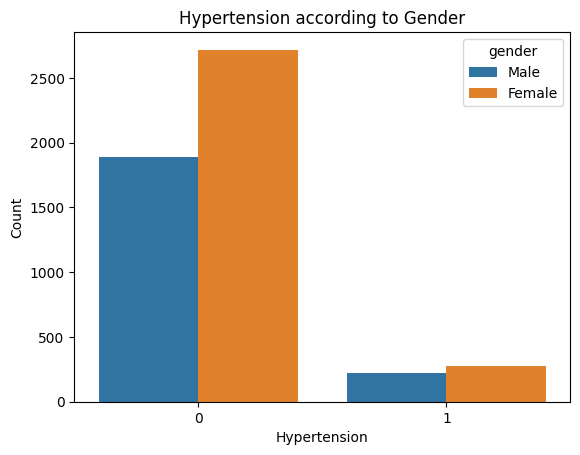

In [43]:
#plot hypertension by gender
sns.countplot(x='hypertension', data=df, hue='gender')
plt.rcParams['figure.figsize'] = (5, 5)
plt.title('Hypertension according to Gender')
plt.xlabel('Hypertension')
plt.ylabel('Count')
plt.show()


In [44]:
#Checking relationship between hypertension and Work_type
print('Counts of Hypertension by Work Type :')
df.pivot_table(index='work_type', columns='hypertension', aggfunc='size', fill_value=0)

Counts of Hypertension by Work Type :


hypertension,0,1
work_type,,
Govt_job,584,73
Never_worked,22,0
Private,2643,281
Self-employed,674,144
children,687,0


In [45]:
#df['work_type'].value_counts()
print('Counts of stroke on presence or absence of hypertension :')
df.pivot_table(index='stroke', columns='hypertension', aggfunc='size', fill_value=0)

Counts of stroke on presence or absence of hypertension :


hypertension,0,1
stroke,,
0,4427,432
1,183,66


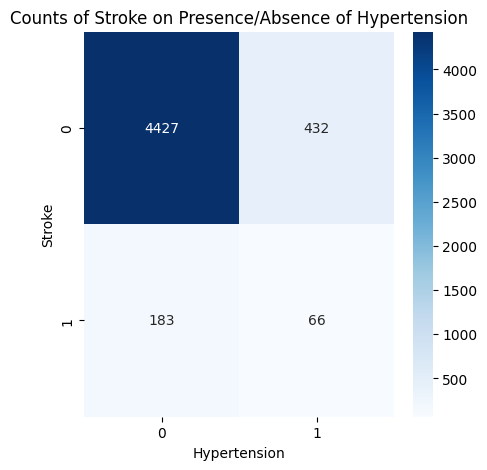

In [46]:
#visualise to see relationship between stroke and hypertension

counts = df.pivot_table(index='stroke', columns='hypertension', aggfunc='size', fill_value=0)

plt.figure(figsize=(5, 5))
sns.heatmap(counts, annot=True, fmt='d', cmap='Blues')

plt.title('Counts of Stroke on Presence/Absence of Hypertension')
plt.xlabel('Hypertension')
plt.ylabel('Stroke')

plt.show()

### Heart_disease

This part is to analyse sample of patients with heart_disease and hypertension and its relation to stroke.

In [47]:
#group heart disease by hypertension to find 
grouped_hh = df.groupby(['heart_disease', 'hypertension']).count()['stroke'].unstack()
grouped_hh

hypertension,0,1
heart_disease,,
0,4398,434
1,212,64


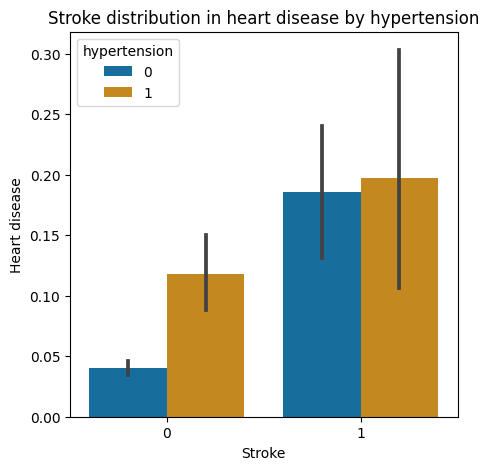

In [48]:
#visualisation of the age distribution of stroke by marital status.
sns.barplot(x='stroke', y='heart_disease', hue='hypertension', data=df, palette='colorblind')

# Add labels and title
plt.xlabel('Stroke')
plt.ylabel('Heart disease')
plt.title('Stroke distribution in heart disease by hypertension')

# Show the plot
plt.show()


As shown above, 64 stroke patients are shown to have heart disease and hypertension, while 434 who presents with hypertension but no heart_disease have stroke. In the same way, a larger sample of the patients 4398 do not have hypertension or heart_disease or stroke.

### Ever_married

In [49]:
#df.head()

In [50]:
#Calculate percentage distribution of ever_married column
df['ever_married'].value_counts(normalize=True).round(4).to_frame() *100

,ever_married
Yes,65.64
No,34.36


In [51]:
#split the 'main df' DataFrame into two new DataFrames,
yes = df[df['ever_married']=='Yes']
no = df[df['ever_married']=='No']

In [52]:
# Calculate the percentage of stroke patients for both groups of married or not
print(f"Percentage of stroke patients among married individuals: {len(yes[yes['stroke']==1])/len(yes):.2f}%")
print(f"Percentage of no_stroke patients among married individuals: {len(yes[yes['stroke']==0])/len(yes):.2f}%")

Percentage of stroke patients among married individuals: 0.07%
Percentage of no_stroke patients among married individuals: 0.93%


In [53]:
# Calculate the percentage of stroke patients for both groups of married or not
print(f"Percentage of stroke patients among unmarried individuals : {len(no[no['stroke']==1])/len(no):.2f}%")
print(f"Percentage of no_stroke patients among unmarried individuals: {len(no[no['stroke']==0])/len(no):.2f}%")

Percentage of stroke patients among unmarried individuals : 0.02%
Percentage of no_stroke patients among unmarried individuals: 0.98%


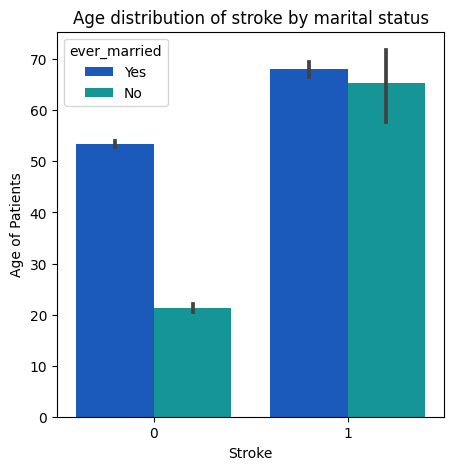

In [54]:
#visualisation of the age distribution of stroke by marital status.
sns.barplot(x='stroke', y='age', hue='ever_married', data=df, palette='winter')

# Add labels and title
plt.xlabel('Stroke')
plt.ylabel('Age of Patients')
plt.title('Age distribution of stroke by marital status')

# Show the plot
plt.show()


### Work_type

In [55]:
#percentage distribution of the work_type in the dataset.
df['work_type'].value_counts(normalize=True).round(4).to_frame(name='Percentage') *100

,Percentage
Private,57.24
Self-employed,16.01
children,13.45
Govt_job,12.86
Never_worked,0.43


In [56]:
# Replace 0 and 1 in 'stroke' with 'No' and 'Yes'
df['stroke'] = df['stroke'].replace({0: 'No', 1: 'Yes'})

# Group the data by work_type and stroke, then count the occurrences
counts_by_work_type_and_stroke = df.groupby(['work_type', 'stroke']).size().reset_index(name='Count')

# Pivot the DataFrame
pivot_table = counts_by_work_type_and_stroke.pivot(index='work_type', columns='stroke', values='Count')

print('Stroke counts by work_type:')
pivot_table

Stroke counts by work_type:


stroke,No,Yes
work_type,,
Govt_job,624.0,33.0
Never_worked,22.0,NaN
Private,2775.0,149.0
Self-employed,753.0,65.0
children,685.0,2.0


From the above, private employees are the most with stroke representing almost 10% of respondents, followed closely by self-employed and govt employees. Never worked groups are completely stroke free from the sample, and children are almost negligible as clearly they do not work. This shows that Job type certainly plays a role in probability of getting stroke.

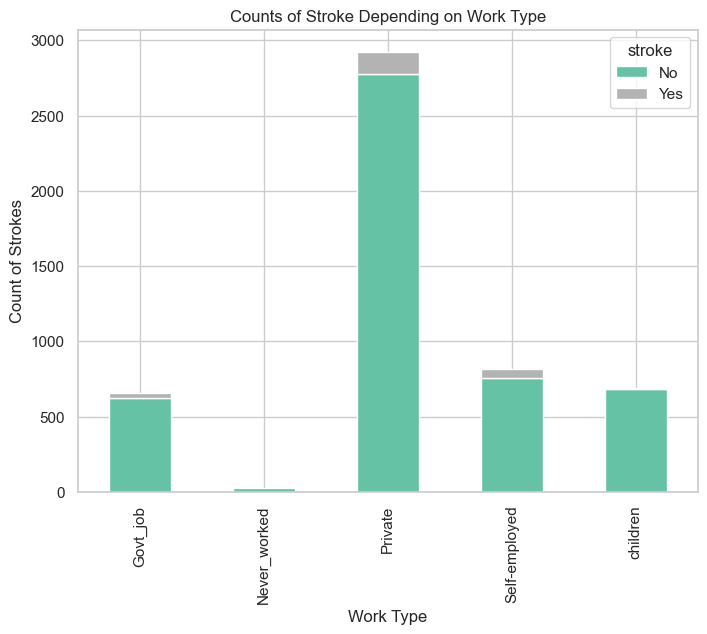

In [57]:
# visualisation of stroke count by work_type
sns.set(style="whitegrid")
pivot_table.plot(kind='bar', stacked=True, colormap='Set2', figsize=(8, 6))

# Add labels and title
plt.xlabel('Work Type')
plt.ylabel('Count of Strokes')
plt.title('Counts of Stroke Depending on Work Type')

# Show the plot
plt.show()

In [58]:
#calculate the mean age for each work_type category
work_type_mean_age = df.groupby('work_type')['age'].mean()
work_type_mean_age

work_type
Govt_job         50.879756
Never_worked     16.181818
Private          45.516758
Self-employed    60.266504
children          6.841339
Name: age, dtype: float64

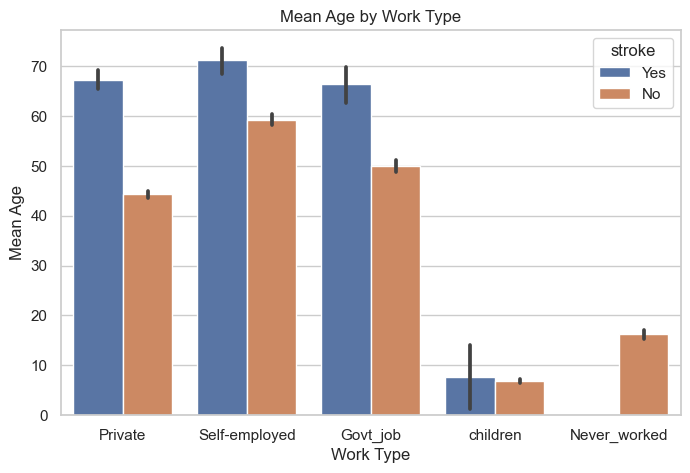

In [59]:
#plot the work type by the mean age category
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='work_type', y='age', hue='stroke')
plt.title('Mean Age by Work Type')
plt.xlabel('Work Type')
plt.ylabel('Mean Age')
plt.show()

### Residence_type

In [60]:
#Residence_type represented as a percentage of the total sample.
df['Residence_type'].value_counts(normalize=True).round(4).to_frame(name='Percentage') *100

,Percentage
Urban,50.8
Rural,49.2


In [61]:
# Replace 0 and 1 in 'stroke' with 'No' and 'Yes'
df['stroke'] = df['stroke'].replace({0: 'No', 1: 'Yes'})

# Group the data by work_type and stroke, then count the occurrences
counts_by_Residence_type_and_stroke = df.groupby(['Residence_type', 'stroke']).size().reset_index(name='Count')

print('Stroke counts by work_type:')

# Pivot the DataFrame
counts_by_Residence_type_and_stroke.pivot(index='Residence_type', columns='stroke', values='Count')

Stroke counts by work_type:


stroke,No,Yes
Residence_type,,
Rural,2399,114
Urban,2460,135


### Avg_glucose_level

In [62]:
#glucose levels categorised according to NLM standards of acceptable average glucose levels
bins = (0, 60, 140, 180,400)
avg_group_names = ['hypoglycemia', 'normal', 'bordering', 'hyperglycemia']
df['diabetes_type'] = pd.cut(df.avg_glucose_level,bins=bins,labels=avg_group_names)

In [63]:
#diabetes category represented as a percentage of the total sample
df['diabetes_type'].value_counts(normalize=True).round(4).to_frame() *100

,diabetes_type
normal,79.62
hyperglycemia,11.41
bordering,4.66
hypoglycemia,4.31


In [64]:
#df.isna().sum()

In [65]:
#checking for the likelihood of each group having stroke
norm = df[df['diabetes_type']=='normal']
bord = df[df['diabetes_type']=='bordering']
hyper = df[df['diabetes_type']=='hyperglycemia']
hypo = df[df['diabetes_type']=='hypoglycemia']

In [66]:
# Replace 0 and 1 in 'stroke' with 'No' and 'Yes'
df['stroke'] = df['stroke'].replace({0: 'No', 1: 'Yes'})

# Group the data by work_type and stroke, then count the occurrences
counts_by_diabetes_and_stroke = df.groupby(['diabetes_type', 'stroke']).size().reset_index(name='Count')

print('Counts of stroke depending on Diabetes category:')

# Pivot the DataFrame
counts_by_diabetes_and_stroke.pivot(index='diabetes_type', columns='stroke', values='Count')

Counts of stroke depending on Diabetes category:


stroke,No,Yes
diabetes_type,,
hypoglycemia,212,8
normal,3919,148
bordering,224,14
hyperglycemia,504,79


In [67]:
#calculate the percentage for normal 'diabetes_type' column
norm.stroke.value_counts(normalize=True).round(3).to_frame() * 100

,stroke
No,96.4
Yes,3.6


In [68]:
#calculate the percentage for bordering 'diabetes_type' column
bord.stroke.value_counts(normalize=True).round(3).to_frame() * 100

,stroke
No,94.1
Yes,5.9


In [69]:
#calculate the percentage for hyperglycemia 'diabetes_type' column
hyper.stroke.value_counts(normalize=True).round(3).to_frame() * 100

,stroke
No,86.4
Yes,13.6


In [70]:
#calculate the percentage for hypoglycemia 'diabetes_type' column
hypo.stroke.value_counts(normalize=True).round(3).to_frame() * 100

,stroke
No,96.4
Yes,3.6


In [71]:
#creating a new dataframe to represent the new variables as a chart
diabetes_by_stroke_df =  pd.DataFrame({ 'stroke': ['Yes', 'No'], 'Normal' : [3.6, 96.4], 'Bordering': [3.7, 96.3],
                    'Hyperglycemia': [10.4, 89.6], 'Hypoglycemia': [3.6, 96.4]})
diabetes_by_stroke_df.index = diabetes_by_stroke_df['stroke']
del diabetes_by_stroke_df['stroke']
diabetes_by_stroke_df

,Normal,Bordering,Hyperglycemia,Hypoglycemia
stroke,,,,
Yes,3.6,3.7,10.4,3.6
No,96.4,96.3,89.6,96.4


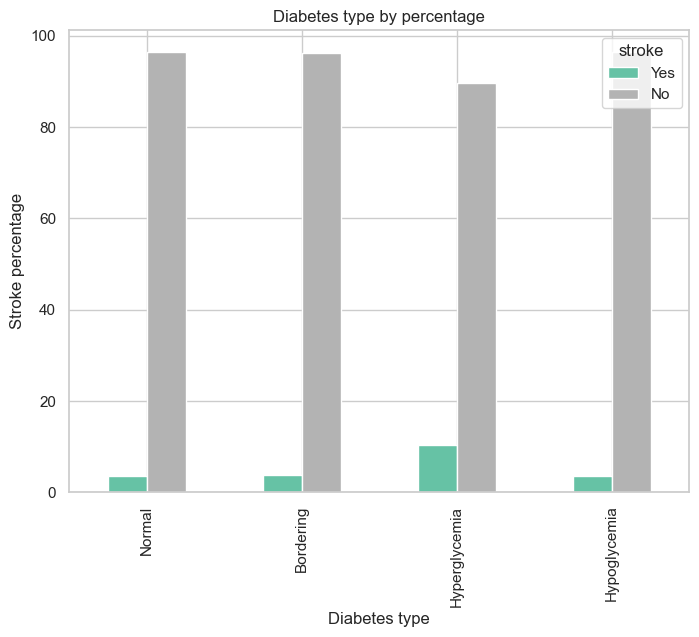

In [72]:
# visualisation of stroke count by diabetes_type
sns.set(style="whitegrid")
diabetes_by_stroke_df.transpose().plot(kind='bar', colormap='Set2', figsize=(8, 6))

# Add labels and title
plt.xlabel('Diabetes type')
plt.ylabel('Stroke percentage')
plt.title('Diabetes type by percentage')

# Show the plot
plt.show()

### BMI

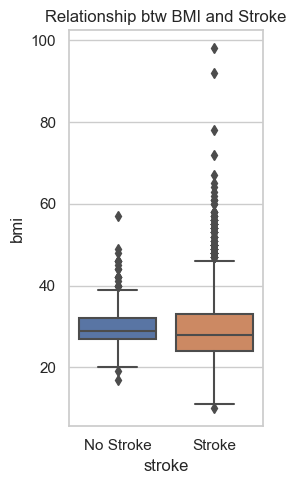

In [73]:
#first show a relationship between the stroke and bmi column

# Box plot: BMI vs. Stroke
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='stroke', y='bmi')
plt.title('Relationship btw BMI and Stroke')
plt.xticks(ticks=[0, 1], labels=['No Stroke', 'Stroke'])

plt.tight_layout()
plt.show()

The plot shows a larger concentration of stroke likelihood between bmi 20-35. BMI can further be categorised into subdivisions of bodymass.
According to WHO report, a bmi less than 18.5, falls under Underweight class,a bmi from 18.5-24.9 falls under Healthy class, those on 25-29.9 falls on Overweight class. 30.0 or higher falls within the obese class.


In [74]:
#creating bins for the different categories
bins = (0, 18.5, 24.9,29.9,100)
group_names = ['Underweight', 'Healthy', 'Overweight', 'Obese']
df['bmi_cat'] = pd.cut(df.bmi,bins=bins,labels=group_names)

In [75]:
#Percentage of different patients' bmi categories 

df['bmi_cat'].value_counts(normalize=True).round(4).to_frame() *100

,bmi_cat
Obese,40.09
Overweight,31.01
Healthy,22.08
Underweight,6.81


In [76]:
# Replace 0 and 1 in 'stroke' with 'No' and 'Yes' respectively
df['stroke'] = df['stroke'].replace({0: 'No', 1: 'Yes'})

# Group the data by bmi_category and stroke, then count the occurrences
counts_by_bmi_cat_and_stroke = df.groupby(['bmi_cat', 'stroke']).size().reset_index(name='Count')

print('Counts of stroke depending on BMI category:')

# Pivot the DataFrame
counts_by_bmi_cat_and_stroke.pivot(index='bmi_cat', columns='stroke', values='Count')

Counts of stroke depending on BMI category:


stroke,No,Yes
bmi_cat,,
Underweight,347,1
Healthy,1094,34
Overweight,1477,107
Obese,1941,107


##### Clear correlation shown between weight class and likelihood to develop stroke, now compare stroke with relation to age and the weight category

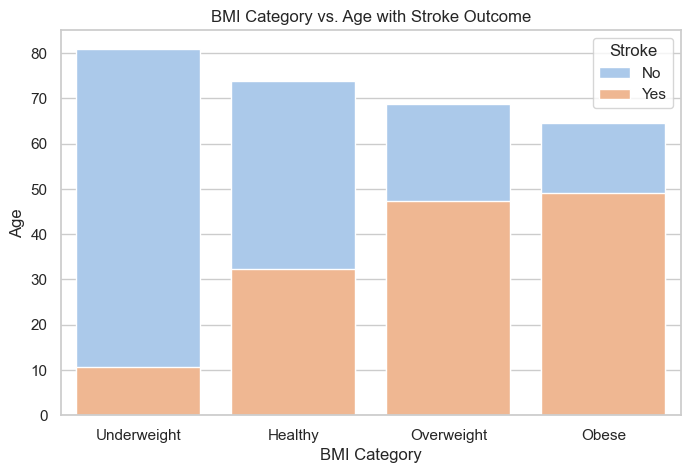

In [77]:
# Create a stacked bar chart
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='bmi_cat', y='age', hue='stroke', ci=None, palette='pastel', dodge=False)
plt.title('BMI Category vs. Age with Stroke Outcome')
plt.xlabel('BMI Category')
plt.ylabel('Age')
plt.legend(title='Stroke', loc='upper right', labels=['No', 'Yes'])
plt.show()


##### While age plays a clear role in stroke diagnosis, it doesn't really influence how each weight class are likely to be with stroke. although overweight and obese weight class patient are more likely to only develop stroke at age forties and above.

In [78]:
df[df['stroke']=='Yes'].gender.value_counts()

Female    141
Male      108
Name: gender, dtype: int64

<Axes: xlabel='age', ylabel='bmi'>

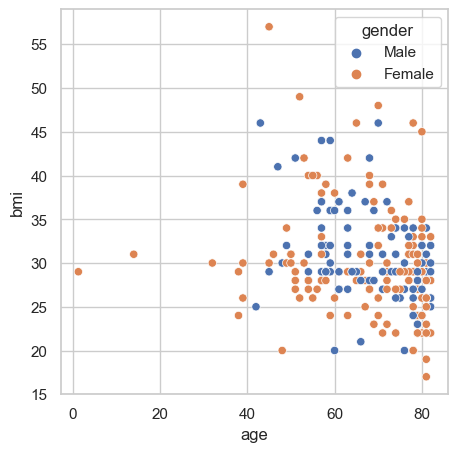

In [79]:
#age and gender distribution of stroke samples
sns.scatterplot(data=df[df['stroke']=='Yes'], y='bmi', x='age',hue='gender')

Distribution shows the stroke being more prevalent with older people (50yrs+)

### Smoking_status

In [80]:
#Each represented as a percentage of the total sample

df['smoking_status'].value_counts(normalize=True).round(4).to_frame() *100

,smoking_status
never smoked,37.04
Unknown,30.19
formerly smoked,17.33
smokes,15.45


The majority of respondents has never smoked, those who smoke are about 15% of the total sample, and the formerly smoked subclass are about 17%. no data was collected from 30% of the sample(recorded as unknown).

so we check the relationship of each group to presence of stroke.

In [81]:
print('Counts of stroke depending on smoking status :')
counts_by_smoking_and_stroke = df.groupby(['smoking_status','stroke']).size().reset_index(name='Count')
counts_by_smoking_and_stroke.pivot(index='smoking_status', columns='stroke', values='Count')

Counts of stroke depending on smoking status :


stroke,No,Yes
smoking_status,,
Unknown,1495,47
formerly smoked,815,70
never smoked,1802,90
smokes,747,42


From the table above, 90 of the stroke sample are from people who have never smoked, followed closely those who fomerly smoked suggesting that stroke may not be directly impacted by smoking.

In [82]:
#group and describe the relationship between stroke and smoking status by age
df[df['stroke']=='Yes'].groupby(['smoking_status']).describe()['age']

,count,mean,std,min,25%,50%,75%,max
smoking_status,,,,,,,,
Unknown,47.0,65.836596,16.236866,1.32,58.0,71.0,77.50,82.0
formerly smoked,70.0,68.628571,10.902960,38.00,63.0,70.0,78.00,82.0
never smoked,90.0,70.311111,11.562866,39.00,63.0,74.0,79.00,82.0
smokes,42.0,62.809524,12.200036,32.00,55.5,61.0,71.75,82.0


As seen, the stoke sample and never or formerly smoked has an average age of 70 and 68 respectively suggesting prevalence of stroke in aged polpulation

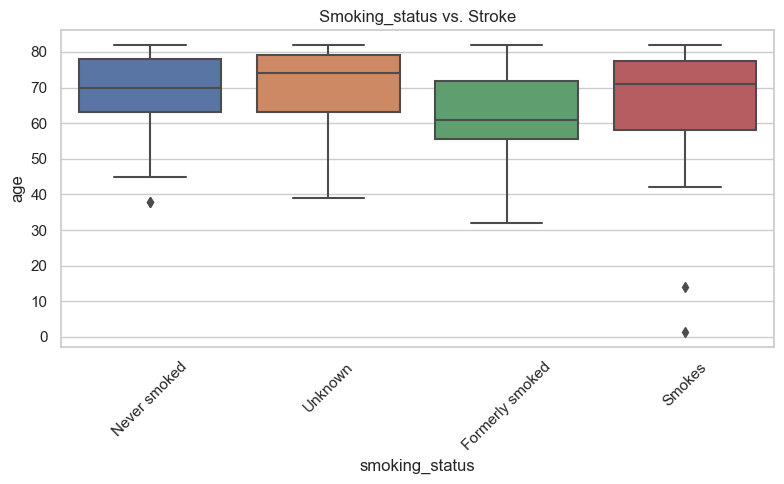

In [83]:
#to represent the relationship between age, smoking status and stroke graphically,

# Box plot: Smoking status vs. Stroke
plt.figure(figsize=(8, 5))
ax = sns.boxplot(data=df[df['stroke']=='Yes'], x='smoking_status', y='age')
plt.title('Smoking_status vs. Stroke')
plt.xticks(rotation=45)
ax.set_xticklabels(['Never smoked', 'Unknown', 'Formerly smoked', 'Smokes'])

plt.tight_layout()
plt.show()

### Feature selection and engineering

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5108 entries, 0 to 5107
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   gender             5108 non-null   object  
 1   age                5108 non-null   float64 
 2   hypertension       5108 non-null   int64   
 3   heart_disease      5108 non-null   int64   
 4   ever_married       5108 non-null   object  
 5   work_type          5108 non-null   object  
 6   Residence_type     5108 non-null   object  
 7   avg_glucose_level  5108 non-null   float64 
 8   bmi                5108 non-null   float64 
 9   smoking_status     5108 non-null   object  
 10  stroke             5108 non-null   object  
 11  age_group          5108 non-null   category
 12  diabetes_cat       5108 non-null   category
 13  age_group_names    5108 non-null   category
 14  diabetes_type      5108 non-null   category
 15  bmi_cat            5108 non-null   category
dtypes: cat

In [85]:
#df

In [86]:
#encode variables using 3 types of encoders
le = LabelEncoder()
oe = OrdinalEncoder()
ohe = OneHotEncoder(drop='first', sparse=False)

In [87]:
# Encode object values
df['gender'] = le.fit_transform(df['gender'])
df['ever_married'] = le.fit_transform(df['ever_married'])
df['Residence_type'] = le.fit_transform(df['Residence_type'])
df['stroke'] = le.fit_transform(df['stroke'])

In [88]:
# Encode categorical values
df['diabetes_type'] = oe.fit_transform(df[['diabetes_type']])
df['age_group_names'] = oe.fit_transform(df[['age_group_names']])
df['bmi_cat'] = oe.fit_transform(df[['bmi_cat']])

In [89]:
#encode using one-hot-encoding
cat_cols = ['work_type', 'smoking_status']
encoded_features = ohe.fit_transform(df[cat_cols])
feature_names = ohe.get_feature_names_out(cat_cols)
encode_ohe_df = pd.DataFrame(encoded_features, columns=feature_names)

In [90]:
df_encoded = pd.concat([df, encode_ohe_df], axis=1)
#df.drop(cat_cols, axis=1, inplace=True)
#df_encoded

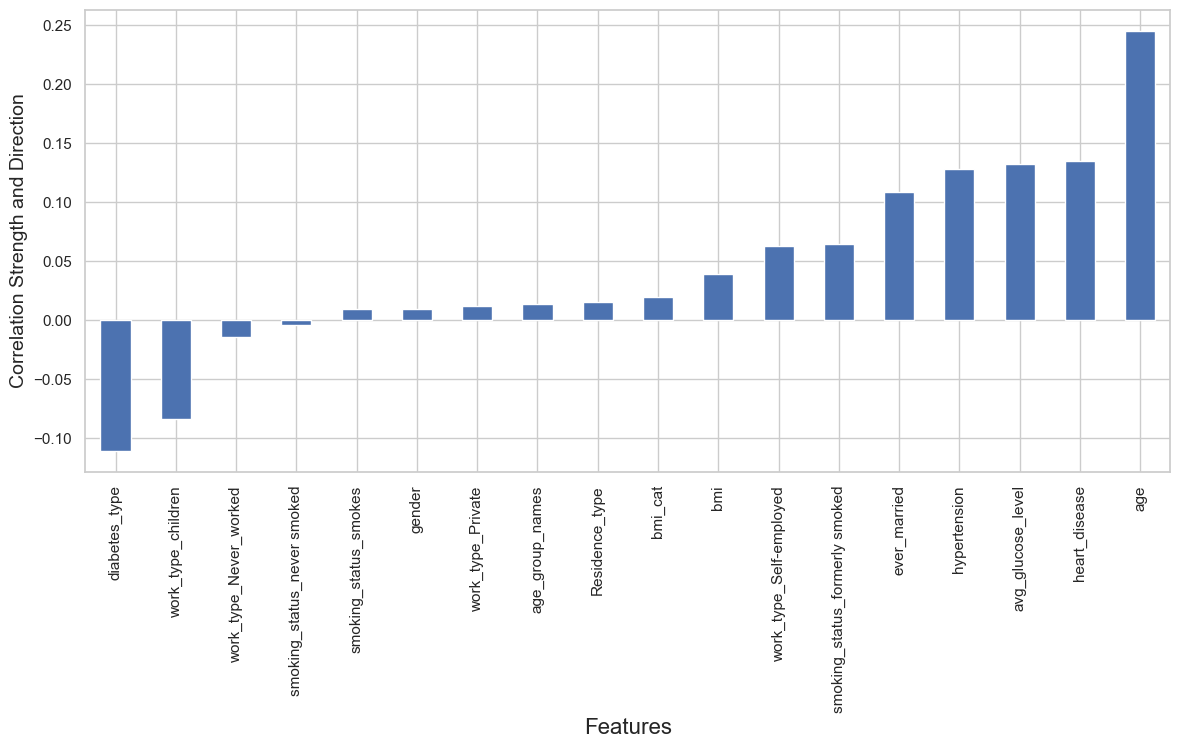

In [91]:
#visualise variables correlation to stroke
plt.figure(figsize=(14,6))
df_encoded.corr()['stroke'].sort_values()[:-1].plot.bar(color='b')
plt.ylabel('Correlation Strength and Direction',fontsize=14)
plt.xlabel('Features',fontsize=16);

### Using Select KBest technique

In [92]:
#df_encoded.columns


In [93]:
# Separate features and target variable
X = df_encoded.drop(['stroke', 'Residence_type', 'age_group', 'work_type', 'smoking_status', 'diabetes_cat', 'age_group_names', 'bmi_cat'], axis=1)
y = df_encoded['stroke']

In [94]:
# Perform feature selection using SelectKBest
selector = SelectKBest(score_func=f_classif, k=5)  # Select top 5 features
X_new = selector.fit_transform(X, y)

# Get selected feature indices and scores
feature_indices = selector.get_support(indices=True)
feature_scores = selector.scores_

# Get names of selected features
selected_features = X.columns[feature_indices]

# Print the selected features and their scores
for feature, score in zip(selected_features, feature_scores[feature_indices]):
    print(f"{feature}: {score:.2f}")

age: 326.74
hypertension: 84.89
heart_disease: 94.64
avg_glucose_level: 90.44
diabetes_type: 63.57


## Model Selection, Training and Evaluation

In [95]:
## Separate features and target variable
X = df[["age", "heart_disease", "avg_glucose_level", "hypertension", "diabetes_type"]]
y = df["stroke"]

In [96]:
names = X.columns
indexes = X.index

scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X, columns=names, index=indexes)
X = X_scaled

In [97]:
#oversampling the minority due to class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_scaled, y)

In [98]:
#split the dataset into train and test set
X_train, X_test, y_train, y_test = train_test_split(X_train_resampled, y_train_resampled, test_size=0.2, random_state=42, stratify = y_train_resampled)

In [99]:
#using gridsearch to select best hyperparameters for tuning
from sklearn.model_selection import GridSearchCV

models = {
    "SVC": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Logistic Regression": LogisticRegression()
}

# Define the hyperparameter grids for each model
param_grids = {
    "SVC": {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]},
    "Decision Tree": {"max_depth": [None, 5, 10, 20], "criterion": ['gini', 'entropy'], 
                      "min_samples_split": [2, 5, 10], "max_features": ["auto", "sqrt", "log2"]},
    "Random Forest": {"n_estimators": [100, 200, 500], "max_depth": [None, 5, 10]},
    "Logistic Regression": {"C": [0.1, 1, 10], "penalty": ["l1", "l2"]}
}

# Perform grid search for each model
for model_name, model in models.items():
    print(f"Tuning hyperparameters for {model_name}...")
    
    # Create a GridSearchCV object with the model and its corresponding parameter grid
    grid_search = GridSearchCV(model, param_grids[model_name], cv=5, scoring="accuracy")
    
    # Fit the GridSearchCV object to the data
    grid_search.fit(X_train, y_train)  # Replace X_train and y_train with your training data
    
    # Print the best parameters and the best score
    print("Best parameters:", grid_search.best_params_)
    print("Best score:", grid_search.best_score_)
    print()


Tuning hyperparameters for SVC...
Best parameters: {'C': 10, 'kernel': 'rbf'}
Best score: 0.7833793094886342

Tuning hyperparameters for Decision Tree...
Best parameters: {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2}
Best score: 0.8734226371525408

Tuning hyperparameters for Random Forest...
Best parameters: {'max_depth': None, 'n_estimators': 500}
Best score: 0.9041669046170654

Tuning hyperparameters for Logistic Regression...
Best parameters: {'C': 0.1, 'penalty': 'l2'}
Best score: 0.7736038105169938



In [100]:
#append the tuned parameters to the models in a list
model_name = {
    "SVC": SVC(C=10, kernel='rbf'),
    "Decision Tree": DecisionTreeClassifier(max_depth=20, criterion='entropy', min_samples_split=2, max_features="auto"),
    "Random Forest": RandomForestClassifier(criterion='gini', max_depth=None, max_features='auto',
                                            min_samples_leaf=10, min_samples_split=4, n_estimators=200),
    "Logistic Regression": LogisticRegression(C=0.1, penalty='l2')
}

# In each model I tried possible matching parameters

### Model fitting

In [101]:
#pass the models through the pipeline, fit and test for scores

def fit_score(model_name, X_train, y_train, X_test, y_test):
    model_test_score = {}
    
    for name, model in model_name.items():
        pipeline = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy="median")),
            ('scaler', MinMaxScaler()),
            (name, model)
        ])
        
        pipeline.fit(X_train, y_train)
        model_test_score[name] = [pipeline.score(X_test, y_test), pipeline]
    
    return model_test_score

# train and test data
X_train, y_train = X_train_resampled, y_train_resampled # training data
X_test, y_test = X_test, y_test   # testing data

results = fit_score(model_name, X_train, y_train, X_test, y_test)

# Print the test scores for each model
for name, (score, _) in results.items():
    print(f"Test score for {name}: {score:.3f}")


Test score for SVC: 0.782
Test score for Decision Tree: 0.986
Test score for Random Forest: 0.907
Test score for Logistic Regression: 0.761


In [102]:
#retrieve the test scores and their corresponding trained models. 
model = fit_score(model_name, X_train, y_train, X_test, y_test)
model

{'SVC': [0.7818930041152263,
  Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                  ('scaler', MinMaxScaler()), ('SVC', SVC(C=10))])],
 'Decision Tree': [0.9768518518518519,
  Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                  ('scaler', MinMaxScaler()),
                  ('Decision Tree',
                   DecisionTreeClassifier(criterion='entropy', max_depth=20,
                                          max_features='auto'))])],
 'Random Forest': [0.9104938271604939,
  Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                  ('scaler', MinMaxScaler()),
                  ('Random Forest',
                   RandomForestClassifier(max_features='auto',
                                          min_samples_leaf=10,
                                          min_samples_split=4,
                                          n_estimators=200))])],
 'Logistic Regression': [0.7613168724279835,
  Pipeline(steps=[('i

### Models Evaluation

In [103]:
def report(model, X_train, y_train, X_test, y_test):
    
    for name, model in model_name.items():
        
        y_train_pred = model.predict(X_train)
        y_pred = model.predict(X_test)
        auc = roc_auc_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        
        print(f'----------------------{name}---------------------------------')
        print("Test_Set")
        print (f'{name} AUC_score = {auc}')
        print(classification_report(y_test, y_pred, zero_division=0))
        plt.figure(figsize=(5, 5))
        sns.set(font_scale=1.2)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=['no_stroke', 'stroke'], yticklabels=['no_stroke', 'stroke'])
        plt.title(f"{name} Confusion Matrix")
        plt.xlabel("Predicted label")
        plt.ylabel("True label")
        plt.savefig(f'{name} confusion matrix')
        plt.show()
        print('------------------------------------------------------------')

----------------------SVC---------------------------------
Test_Set
SVC AUC_score = 0.7818930041152263
              precision    recall  f1-score   support

           0       0.80      0.76      0.78       972
           1       0.77      0.80      0.79       972

    accuracy                           0.78      1944
   macro avg       0.78      0.78      0.78      1944
weighted avg       0.78      0.78      0.78      1944



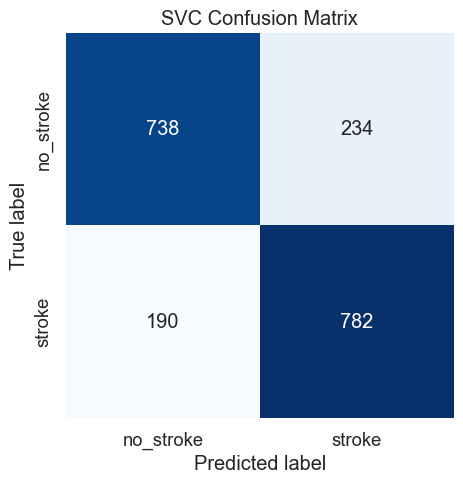

------------------------------------------------------------
----------------------Decision Tree---------------------------------
Test_Set
Decision Tree AUC_score = 0.976851851851852
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       972
           1       0.96      0.99      0.98       972

    accuracy                           0.98      1944
   macro avg       0.98      0.98      0.98      1944
weighted avg       0.98      0.98      0.98      1944



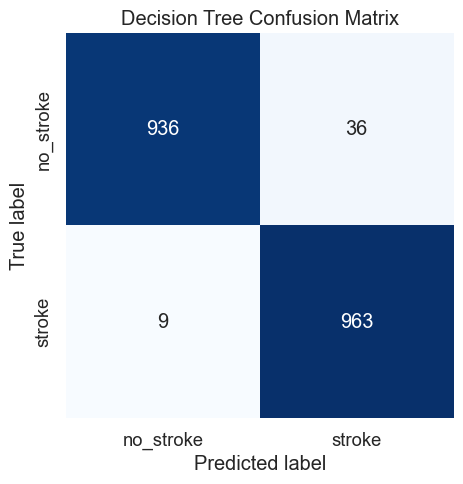

------------------------------------------------------------
----------------------Random Forest---------------------------------
Test_Set
Random Forest AUC_score = 0.9104938271604939
              precision    recall  f1-score   support

           0       0.94      0.88      0.91       972
           1       0.89      0.94      0.91       972

    accuracy                           0.91      1944
   macro avg       0.91      0.91      0.91      1944
weighted avg       0.91      0.91      0.91      1944



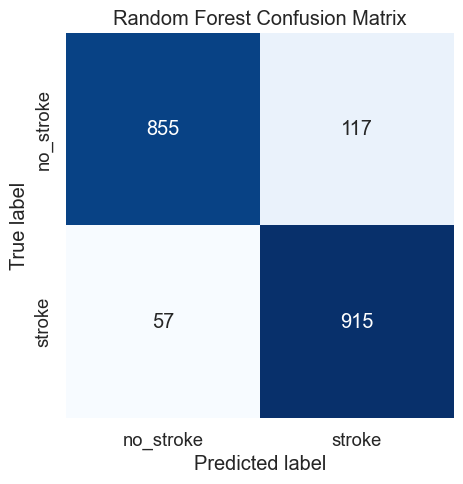

------------------------------------------------------------
----------------------Logistic Regression---------------------------------
Test_Set
Logistic Regression AUC_score = 0.7613168724279835
              precision    recall  f1-score   support

           0       0.77      0.74      0.76       972
           1       0.75      0.78      0.77       972

    accuracy                           0.76      1944
   macro avg       0.76      0.76      0.76      1944
weighted avg       0.76      0.76      0.76      1944



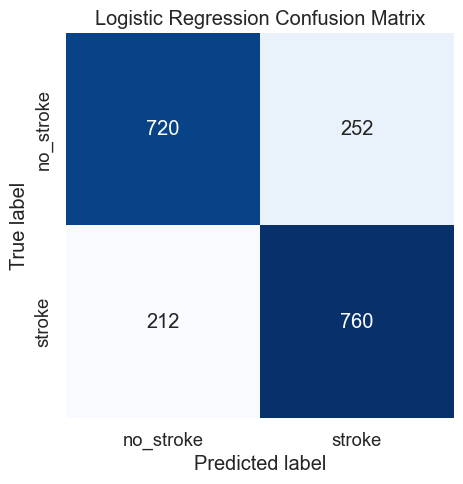

------------------------------------------------------------


In [104]:
from sklearn.metrics import classification_report

report(model_name, X_train, y_train, X_test, y_test)

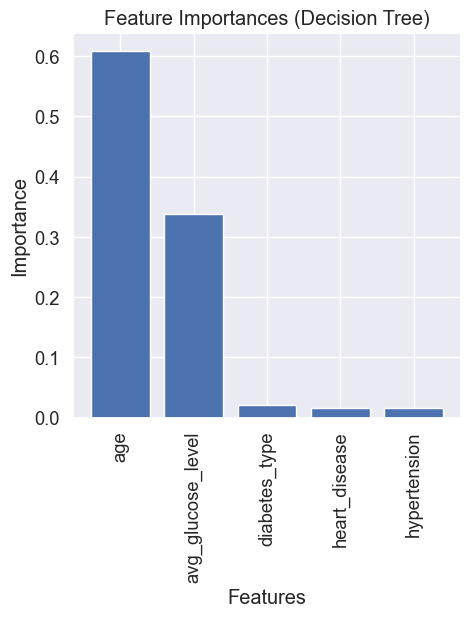

In [105]:
# Get feature importances for Decision Tree
importances = model['Decision Tree'][1]['Decision Tree'].feature_importances_
features = X.columns

# Sort feature importances in descending order
indices = np.argsort(importances)[::-1]
# Plot feature importances
plt.figure(figsize=(5, 5))
plt.bar(range(len(features)), importances[indices])
plt.xticks(range(len(features)), features[indices], rotation='vertical')
plt.title('Feature Importances (Decision Tree)')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()

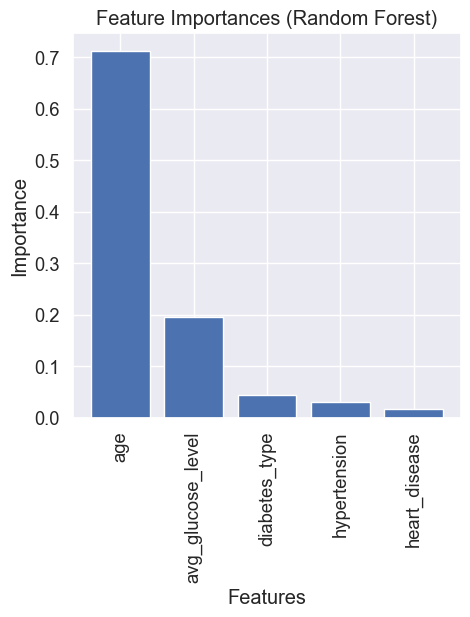

In [106]:
# Get feature importances for Random Forest
importances = model['Random Forest'][1]['Random Forest'].feature_importances_
features = X.columns

# Sort feature importances in descending order
indices = np.argsort(importances)[::-1]
# Plot feature importances
plt.figure(figsize=(5, 5))
plt.bar(range(len(features)), importances[indices])
plt.xticks(range(len(features)), features[indices], rotation='vertical')
plt.title('Feature Importances (Random Forest)')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()

In [107]:
#df.info()


### LSTM Model

In [108]:
# Define the features and target variable
X_features = df[["age", "heart_disease", "avg_glucose_level", "hypertension", "diabetes_type", "gender", "bmi_cat", "ever_married"]]
y_target = df['stroke']

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_features)

# Oversampling the minority due to class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_target)

# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_train_resampled, y_train_resampled, test_size=0.3, random_state=42, stratify=y_train_resampled)

# Reshape the data for LSTM input
X_train_reshaped = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_reshaped = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [109]:
#libraries
from keras.models import Sequential
from keras.layers import LSTM, Dense

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, activation='relu', return_sequences=True, input_shape=(X_train_reshaped.shape[1], 1)))
model.add(LSTM(units=50, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_data=(X_test_reshaped, y_test))

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test_reshaped, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Epoch 1/10
213/213 [==============================] - 10s 20ms/step - loss: 0.5362 - accuracy: 0.7398 - val_loss: 0.4944 - val_accuracy: 0.7675
Epoch 2/10
213/213 [==============================] - 3s 16ms/step - loss: 0.4788 - accuracy: 0.7782 - val_loss: 0.4715 - val_accuracy: 0.7719
Epoch 3/10
213/213 [==============================] - 3s 16ms/step - loss: 0.4714 - accuracy: 0.7801 - val_loss: 0.4716 - val_accuracy: 0.7713
Epoch 4/10
213/213 [==============================] - 3s 16ms/step - loss: 0.4711 - accuracy: 0.7790 - val_loss: 0.4833 - val_accuracy: 0.7726
Epoch 5/10
213/213 [==============================] - 3s 16ms/step - loss: 0.4660 - accuracy: 0.7790 - val_loss: 0.4659 - val_accuracy: 0.7695
Epoch 6/10
213/213 [==============================] - 3s 15ms/step - loss: 0.4636 - accuracy: 0.7793 - val_loss: 0.4728 - val_accuracy: 0.7706
Epoch 7/10
213/213 [==============================] - 3s 16ms/step - loss: 0.4632 - accuracy: 0.7774 - val_loss: 0.4643 - val_accuracy: 0.770

In [110]:
from sklearn.metrics import classification_report

# Predict on the test set
y_pred = model.predict(X_test_reshaped)
y_pred = (y_pred > 0.5)

auc = roc_auc_score(y_test, y_pred)
print(f'auc score:{auc}')

#show classification report
print(classification_report(y_true = y_test, y_pred=y_pred, target_names=['no_stroke', 'stroke']))

92/92 [==============================] - 1s 6ms/step
auc score:0.77400548696845
              precision    recall  f1-score   support

   no_stroke       0.82      0.71      0.76      1458
      stroke       0.74      0.84      0.79      1458

    accuracy                           0.77      2916
   macro avg       0.78      0.77      0.77      2916
weighted avg       0.78      0.77      0.77      2916



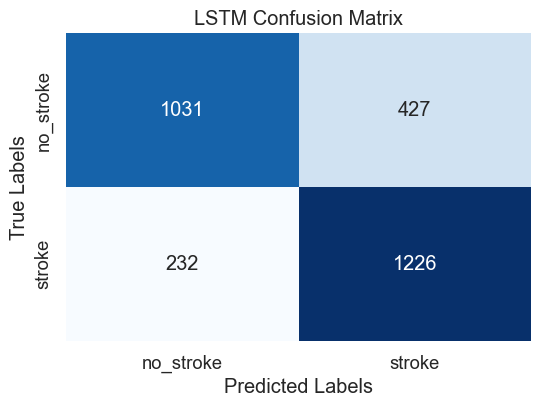

In [111]:
#get confusion matrix
confusion = confusion_matrix(y_test, y_pred)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=['no_stroke', 'stroke'], yticklabels=['no_stroke', 'stroke'])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("LSTM Confusion Matrix")
plt.show()

Epoch 1/10
213/213 [==============================] - 3s 16ms/step - loss: 0.4559 - accuracy: 0.7820 - val_loss: 0.4571 - val_accuracy: 0.7791
Epoch 2/10
213/213 [==============================] - 4s 17ms/step - loss: 0.4522 - accuracy: 0.7820 - val_loss: 0.4548 - val_accuracy: 0.7767
Epoch 3/10
213/213 [==============================] - 4s 17ms/step - loss: 0.4513 - accuracy: 0.7846 - val_loss: 0.4695 - val_accuracy: 0.7761
Epoch 4/10
213/213 [==============================] - 3s 15ms/step - loss: 0.4492 - accuracy: 0.7834 - val_loss: 0.4553 - val_accuracy: 0.7778
Epoch 5/10
213/213 [==============================] - 3s 15ms/step - loss: 0.4497 - accuracy: 0.7811 - val_loss: 0.4507 - val_accuracy: 0.7774
Epoch 6/10
213/213 [==============================] - 3s 16ms/step - loss: 0.4473 - accuracy: 0.7852 - val_loss: 0.4523 - val_accuracy: 0.7791
Epoch 7/10
213/213 [==============================] - 3s 15ms/step - loss: 0.4462 - accuracy: 0.7849 - val_loss: 0.4477 - val_accuracy: 0.7833

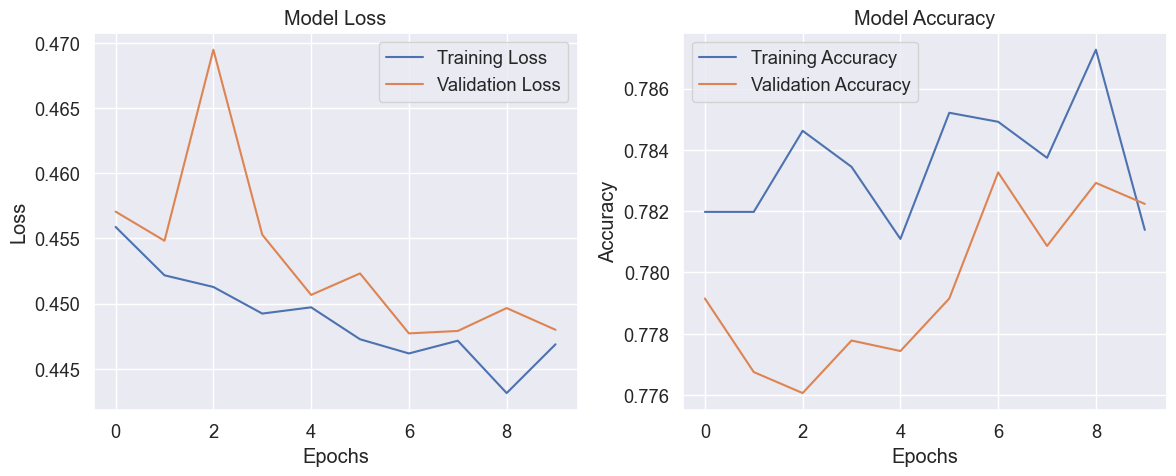

In [112]:
#evaluating to check for overfitting
# Train the model while tracking performance
history = model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, 
                    validation_data=(X_test_reshaped, y_test), verbose=1)

# Extract training history
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Create a learning curve plot
plt.figure(figsize=(12, 5))

# Plot training & validation loss values
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot training & validation accuracy values
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()